# Project Assignment B: Network Structure and Community Language

**Central question:** Do actor collaboration communities specialize in different thematic language, and which actors bridge these communities?

This notebook extends Assignment A with deeper Week 4-8 methods: weighted networks, centrality, community detection, heavy-tail diagnostics, and TF-IDF at community level.

## Assignment B Alignment and Roadmap

1. Motivation and scope
2. Basic statistics and diagnostics
3. Tools, theory, and analysis (network + text)
4. Discussion, limitations, and next steps

### What is new vs Assignment A
- Adds weighted actor co-appearance graph diagnostics and centrality ranking.
- Adds Louvain communities and modularity-based interpretation.
- Adds community-level text profiling with TF and TF-IDF.

### Scope boundaries
- Included: processed data analysis, network/text integration, reproducible outputs.
- Excluded: website implementation, deep learning NLP, and fresh TMDB recrawl.

In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from datetime import datetime, UTC
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

try:
    import community as community_louvain
except Exception as exc:
    raise ImportError('python-louvain is required. Install it before running this notebook.') from exc

SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data' / 'processed'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

print(f'Root: {ROOT}')
print(f'Data: {DATA_DIR}')
print(f'Outputs: {OUTPUT_DIR}')

Root: /home/mattis/PycharmProjects/Project-Assignment-CSS
Data: /home/mattis/PycharmProjects/Project-Assignment-CSS/data/processed
Outputs: /home/mattis/PycharmProjects/Project-Assignment-CSS/outputs


In [2]:
def load_table(base_name: str) -> pd.DataFrame:
    parquet_path = DATA_DIR / f'{base_name}.parquet'
    csv_path = DATA_DIR / f'{base_name}.csv'
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f'Could not find {base_name}.parquet or {base_name}.csv in {DATA_DIR}')

actors = load_table('actors')
movies = load_table('movies')
actor_movie = load_table('actor_movie')

movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_year'] = movies['release_date'].dt.year

print('Shapes:')
print('actors:', actors.shape)
print('movies:', movies.shape)
print('actor_movie:', actor_movie.shape)

display(actors.head(3))
display(movies.head(3))
display(actor_movie.head(3))

Shapes:
actors: (1392, 5)
movies: (200, 9)
actor_movie: (1797, 4)


,actor_id,name,gender,known_for_department,popularity
0,65731,Sam Worthington,2,Acting,4.1431
1,8691,Zoe Saldaña,1,Acting,5.3779
2,10205,Sigourney Weaver,1,Acting,4.2315


,movie_id,title,release_date,vote_average,vote_count,popularity,overview,genres,release_year
0,83533,Avatar: Fire and Ash,2025-12-17,7.371,2672,295.9826,In the wake of the devastating war against the...,"[Science Fiction, Adventure, Fantasy]",2025
1,502356,The Super Mario Bros. Movie,2023-04-05,7.587,10502,146.0888,"While working underground to fix a water main,...","[Family, Comedy, Adventure, Fantasy, Animation]",2023
2,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.680,804,126.5247,The Demon Slayer Corps are drawn into the Infi...,"[Animation, Action, Fantasy]",2025


,actor_id,movie_id,character,cast_order
0,65731,83533,Jake,0
1,8691,83533,Neytiri,1
2,10205,83533,Kiri,2


In [4]:
required_cols = {
    'actors': {'actor_id', 'name', 'gender', 'known_for_department', 'popularity'},
    'movies': {'movie_id', 'title', 'release_date', 'vote_average', 'vote_count', 'popularity', 'overview', 'genres'},
    'actor_movie': {'actor_id', 'movie_id', 'character', 'cast_order'},
}

actual_tables = {'actors': actors, 'movies': movies, 'actor_movie': actor_movie}
for table_name, required in required_cols.items():
    missing = required - set(actual_tables[table_name].columns)
    assert not missing, f'{table_name} is missing columns: {missing}'

sanity_rows = []
for table_name, df in actual_tables.items():
    safe_df = df.copy()
    for col in safe_df.columns:
        if safe_df[col].dtype == 'object':
            safe_df[col] = safe_df[col].map(lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x)

    sanity_rows.append({
        'table': table_name,
        'rows': len(df),
        'columns': len(df.columns),
        'null_cells': int(df.isna().sum().sum()),
        'duplicate_rows': int(safe_df.duplicated().sum()),
    })

sanity_df = pd.DataFrame(sanity_rows).sort_values('table').reset_index(drop=True)
sanity_df.to_csv(OUTPUT_DIR / 'table_dataset_summary_b.csv', index=False)
display(sanity_df)

,table,rows,columns,null_cells,duplicate_rows
0,actor_movie,1797,4,0,0
1,actors,1392,5,0,0
2,movies,200,9,0,0


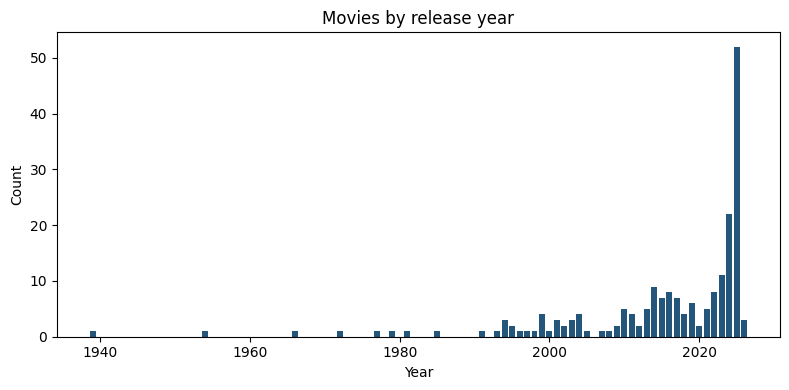

,genre,count
0,Adventure,84
1,Action,83
2,Science Fiction,62
3,Drama,52
4,Thriller,50
5,Comedy,46
6,Animation,39
7,Fantasy,35
8,Family,35
9,Horror,25


,stat,cast_order
0,count,1797.000000
1,mean,3.993879
2,std,2.580436
3,min,0.000000
4,25%,2.000000
5,50%,4.000000
6,75%,6.000000
7,max,8.000000


In [5]:
genres_long = (
    movies[['movie_id', 'genres']]
    .explode('genres')
    .dropna(subset=['genres'])
    .rename(columns={'genres': 'genre'})
)
genre_counts = genres_long['genre'].value_counts().rename_axis('genre').reset_index(name='count')
year_counts = movies['release_year'].dropna().astype(int).value_counts().sort_index().rename_axis('release_year').reset_index(name='count')
cast_order_stats = actor_movie['cast_order'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame(name='cast_order').reset_index().rename(columns={'index': 'stat'})

genre_counts.to_csv(OUTPUT_DIR / 'table_genre_counts_b.csv', index=False)
year_counts.to_csv(OUTPUT_DIR / 'table_release_year_counts_b.csv', index=False)
cast_order_stats.to_csv(OUTPUT_DIR / 'table_cast_order_stats_b.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(year_counts['release_year'], year_counts['count'], color='#24557a')
ax.set_title('Movies by release year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_release_year_distribution_b.png', dpi=150)
plt.show()

display(genre_counts.head(15))
display(cast_order_stats)

In [ ]:
actor_degree = actor_movie.groupby('actor_id')['movie_id'].nunique().rename('num_movies').reset_index()
actor_degree = actor_degree.merge(actors[['actor_id', 'name']], on='actor_id', how='left')

summary = actor_degree['num_movies'].describe(percentiles=[0.25, 0.5, 0.75]).to_dict()
iqr = summary['75%'] - summary['25%']
print(f"Mean={summary['mean']:.2f}, Median={summary['50%']:.2f}, IQR={iqr:.2f}, Max={summary['max']:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(actor_degree['num_movies'], bins=20, color='#4b7f52', edgecolor='white')
axes[0].set_title('Actor degree (linear scale)')
axes[0].set_xlabel('Distinct movies per actor')
axes[0].set_ylabel('Frequency')

axes[1].hist(actor_degree['num_movies'], bins=20, color='#4b7f52', edgecolor='white', log=True)
axes[1].set_title('Actor degree (log y-scale)')
axes[1].set_xlabel('Distinct movies per actor')
axes[1].set_ylabel('Frequency (log)')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_actor_degree_hist_b.png', dpi=150)
plt.show()

### Heavy-tail interpretation
The degree distribution is right-skewed: many actors appear in relatively few sampled movies, while a smaller set appears broadly. This is consistent with qualitative heavy-tail behavior expected in collaboration networks. We do not claim a formal power-law fit because no dedicated goodness-of-fit test is performed in this notebook.

In [ ]:
movie_to_actors = actor_movie.groupby('movie_id')['actor_id'].apply(lambda s: sorted(set(s))).to_dict()

G = nx.Graph()
G.add_nodes_from(actors['actor_id'].tolist())

for actor_ids in movie_to_actors.values():
    if len(actor_ids) < 2:
        continue
    for u, v in combinations(actor_ids, 2):
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)

actor_attr = actors.set_index('actor_id').to_dict('index')
for node in G.nodes:
    attrs = actor_attr.get(node, {})
    for k, v in attrs.items():
        G.nodes[node][k] = v

components = sorted(nx.connected_components(G), key=len, reverse=True)
gcc_nodes = components[0] if components else set()
G_gcc = G.subgraph(gcc_nodes).copy()

print(f'Full graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'GCC graph: {G_gcc.number_of_nodes()} nodes, {G_gcc.number_of_edges()} edges')

In [ ]:
n = G.number_of_nodes()
density = nx.density(G)
num_components = nx.number_connected_components(G)
isolates = nx.number_of_isolates(G)
avg_clustering = nx.average_clustering(G, weight='weight') if G.number_of_edges() > 0 else float('nan')

structural_metrics = pd.DataFrame([
    {'metric': 'nodes', 'value': n},
    {'metric': 'edges', 'value': G.number_of_edges()},
    {'metric': 'density', 'value': density},
    {'metric': 'connected_components', 'value': num_components},
    {'metric': 'isolates', 'value': isolates},
    {'metric': 'gcc_nodes', 'value': G_gcc.number_of_nodes()},
    {'metric': 'gcc_edges', 'value': G_gcc.number_of_edges()},
    {'metric': 'average_clustering_weighted', 'value': avg_clustering},
])

if G_gcc.number_of_nodes() > 1 and G_gcc.number_of_edges() > 0:
    structural_metrics = pd.concat([
        structural_metrics,
        pd.DataFrame([{'metric': 'avg_shortest_path_gcc', 'value': nx.average_shortest_path_length(G_gcc)}]),
    ], ignore_index=True)

structural_metrics.to_csv(OUTPUT_DIR / 'table_network_metrics_b.csv', index=False)
display(structural_metrics)

In [ ]:
strength = dict(G.degree(weight='weight'))
degree = dict(G.degree())

if G_gcc.number_of_nodes() > 1 and G_gcc.number_of_edges() > 0:
    closeness_gcc = nx.closeness_centrality(G_gcc)
    betweenness_gcc = nx.betweenness_centrality(G_gcc, normalized=True, weight=None)
    try:
        eigen_gcc = nx.eigenvector_centrality(G_gcc, max_iter=2000, tol=1e-06)
    except nx.PowerIterationFailedConvergence:
        eigen_gcc = {node: np.nan for node in G_gcc.nodes()}
else:
    closeness_gcc = {}
    betweenness_gcc = {}
    eigen_gcc = {}

centrality_rows = []
for actor_id in G.nodes():
    centrality_rows.append({
        'actor_id': actor_id,
        'name': G.nodes[actor_id].get('name'),
        'degree': degree.get(actor_id, 0),
        'strength': strength.get(actor_id, 0.0),
        'closeness_gcc': closeness_gcc.get(actor_id, np.nan),
        'betweenness_gcc': betweenness_gcc.get(actor_id, np.nan),
        'eigenvector_gcc': eigen_gcc.get(actor_id, np.nan),
    })

centrality_df = pd.DataFrame(centrality_rows).sort_values(['strength', 'degree'], ascending=False).reset_index(drop=True)
centrality_df.to_csv(OUTPUT_DIR / 'table_top_central_actors_b.csv', index=False)
display(centrality_df.head(20))

In [ ]:
assortativity_rows = []
try:
    assortativity_rows.append({'metric': 'degree_assortativity', 'value': nx.degree_assortativity_coefficient(G)})
except Exception:
    assortativity_rows.append({'metric': 'degree_assortativity', 'value': np.nan})

gender_available = actors['gender'].notna().mean()
if gender_available > 0.8:
    try:
        assortativity_rows.append({'metric': 'gender_assortativity', 'value': nx.attribute_assortativity_coefficient(G, 'gender')})
    except Exception:
        assortativity_rows.append({'metric': 'gender_assortativity', 'value': np.nan})

assortativity_df = pd.DataFrame(assortativity_rows)
assortativity_df.to_csv(OUTPUT_DIR / 'table_assortativity_b.csv', index=False)
display(assortativity_df)

In [ ]:
partition = community_louvain.best_partition(G_gcc, random_state=SEED, weight='weight') if G_gcc.number_of_nodes() else {}
modularity = community_louvain.modularity(partition, G_gcc, weight='weight') if partition else np.nan

community_df = pd.DataFrame({
    'actor_id': list(partition.keys()),
    'community': list(partition.values()),
})
community_df = community_df.merge(actors[['actor_id', 'name']], on='actor_id', how='left')

community_sizes = community_df['community'].value_counts().rename_axis('community').reset_index(name='size').sort_values('size', ascending=False)
community_sizes.to_csv(OUTPUT_DIR / 'table_community_sizes_b.csv', index=False)
community_df.to_csv(OUTPUT_DIR / 'table_actor_community_b.csv', index=False)

print(f'Number of communities: {community_sizes.shape[0]}')
print(f'Modularity: {modularity:.4f}')
display(community_sizes.head(20))

In [ ]:
community_central = centrality_df.merge(community_df[['actor_id', 'community']], on='actor_id', how='left')
top_per_community = (
    community_central.dropna(subset=['community'])
    .sort_values(['community', 'strength', 'degree'], ascending=[True, False, False])
    .groupby('community')
    .head(10)
    .reset_index(drop=True)
)
top_per_community.to_csv(OUTPUT_DIR / 'table_top_actors_per_community_b.csv', index=False)
display(top_per_community.head(30))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(community_sizes['community'].astype(str), community_sizes['size'], color='#a84d2b')
ax.set_title('Louvain community sizes')
ax.set_xlabel('Community')
ax.set_ylabel('Actors')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_community_sizes_b.png', dpi=150)
plt.show()

sample_n = min(250, G_gcc.number_of_nodes())
if sample_n > 0:
    sorted_nodes = sorted(G_gcc.nodes(), key=lambda x: G_gcc.degree(x, weight='weight'), reverse=True)
    sample_nodes = sorted_nodes[:sample_n]
    G_sample = G_gcc.subgraph(sample_nodes).copy()

    comm_values = [partition.get(n, -1) for n in G_sample.nodes()]
    pos = nx.spring_layout(G_sample, seed=SEED, k=0.25)

    fig, ax = plt.subplots(figsize=(8, 8))
    nx.draw_networkx_nodes(G_sample, pos=pos, node_size=35, node_color=comm_values, cmap='tab20', ax=ax, alpha=0.9)
    nx.draw_networkx_edges(G_sample, pos=pos, width=0.2, alpha=0.25, ax=ax)
    ax.set_title('Community-colored actor network sample (top-strength nodes)')
    ax.axis('off')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'fig_network_community_sample_b.png', dpi=150)
    plt.show()

In [ ]:
STOPWORDS = {
    'film', 'movie', 'one', 'two', 'new', 'find', 'must', 'story', 'life', 'world', 'man', 'woman',
    'young', 'old', 'family', 'take', 'takes', 'gets', 'get', 'set', 'based', 'across', 'whose'
}

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if len(t) >= 3 and t not in STOPWORDS]
    return ' '.join(tokens)

movie_text = movies[['movie_id', 'overview']].copy()
movie_text['clean_overview'] = movie_text['overview'].fillna('').map(normalize_text)

actor_comm = community_df[['actor_id', 'community']].drop_duplicates()
actor_movie_comm = actor_movie[['actor_id', 'movie_id']].merge(actor_comm, on='actor_id', how='inner')

community_movie = actor_movie_comm[['community', 'movie_id']].drop_duplicates()
community_docs = community_movie.merge(movie_text[['movie_id', 'clean_overview']], on='movie_id', how='left')
community_docs = (
    community_docs.groupby('community')['clean_overview']
    .apply(lambda s: ' '.join([x for x in s if isinstance(x, str) and x]))
    .reset_index(name='document')
)

assert not community_docs.empty, 'Community documents are empty'
display(community_docs.head())

In [ ]:
def extract_top_terms(matrix, feature_names, communities, top_k=15):
    rows = []
    dense = matrix.toarray()
    for i, comm in enumerate(communities):
        scores = dense[i]
        top_idx = np.argsort(scores)[::-1][:top_k]
        for rank, idx in enumerate(top_idx, start=1):
            score = float(scores[idx])
            if score <= 0:
                continue
            rows.append({
                'community': int(comm),
                'rank': rank,
                'term': feature_names[idx],
                'score': score,
            })
    return pd.DataFrame(rows)

docs = community_docs['document'].fillna('').tolist()
comms = community_docs['community'].tolist()

count_vectorizer = CountVectorizer(stop_words='english', min_df=1, max_df=0.95)
tf_matrix = count_vectorizer.fit_transform(docs)
tf_df = extract_top_terms(tf_matrix, count_vectorizer.get_feature_names_out(), comms, top_k=20)
tf_df.to_csv(OUTPUT_DIR / 'table_tf_terms_b.csv', index=False)

tfidf_vectorizer = TfidfVectorizer(stop_words='english', min_df=1, max_df=0.95)
tfidf_matrix = tfidf_vectorizer.fit_transform(docs)
tfidf_df = extract_top_terms(tfidf_matrix, tfidf_vectorizer.get_feature_names_out(), comms, top_k=20)
tfidf_df.to_csv(OUTPUT_DIR / 'table_tfidf_terms_b.csv', index=False)

display(tf_df.head(20))
display(tfidf_df.head(20))

In [ ]:
focus_communities = community_sizes.head(4)['community'].tolist()
plot_data = tfidf_df[tfidf_df['community'].isin(focus_communities) & (tfidf_df['rank'] <= 10)].copy()

fig, axes = plt.subplots(len(focus_communities), 1, figsize=(8, 2.5 * max(1, len(focus_communities))))
if len(focus_communities) == 1:
    axes = [axes]

for ax, comm in zip(axes, focus_communities):
    sub = plot_data[plot_data['community'] == comm].sort_values('score', ascending=True)
    ax.barh(sub['term'], sub['score'], color='#2d6b8a')
    ax.set_title(f'Community {comm}: top TF-IDF terms')
    ax.set_xlabel('TF-IDF score')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_tfidf_terms_by_community_b.png', dpi=150)
plt.show()

try:
    from wordcloud import WordCloud

    for comm in focus_communities:
        freq = {r['term']: r['score'] for _, r in tfidf_df[tfidf_df['community'] == comm].head(100).iterrows()}
        if not freq:
            continue
        wc = WordCloud(width=800, height=400, background_color='white', random_state=SEED).generate_from_frequencies(freq)
        plt.figure(figsize=(8, 4))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Community {comm} word cloud (TF-IDF)')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f'fig_wordcloud_community_{comm}_b.png', dpi=150)
        plt.show()
except Exception as exc:
    print(f'WordCloud unavailable ({exc}); bar charts already provide fallback interpretation.')

In [ ]:
assert G.number_of_nodes() > 0, 'Graph has no nodes'
assert G.number_of_edges() > 0, 'Graph has no edges'
assert not centrality_df.empty, 'Centrality output is empty'
assert not community_sizes.empty, 'Community sizes output is empty'
assert {'community', 'term', 'score'}.issubset(tfidf_df.columns), 'TF-IDF output missing expected columns'

run_metadata = {
    'timestamp_utc': datetime.now(UTC).isoformat(),
    'seed': SEED,
    'input_shapes': {
        'actors': list(actors.shape),
        'movies': list(movies.shape),
        'actor_movie': list(actor_movie.shape),
    },
    'graph': {
        'nodes': int(G.number_of_nodes()),
        'edges': int(G.number_of_edges()),
        'gcc_nodes': int(G_gcc.number_of_nodes()),
        'gcc_edges': int(G_gcc.number_of_edges()),
    },
    'communities': {
        'count': int(community_sizes.shape[0]),
        'modularity': None if pd.isna(modularity) else float(modularity),
    },
}

with open(OUTPUT_DIR / 'run_metadata_b.json', 'w', encoding='utf-8') as f:
    json.dump(run_metadata, f, indent=2)

print('Validation checks passed and run metadata saved.')

## Discussion

### What worked
- The weighted actor network is connected enough to support robust centrality and community analysis.
- Louvain produced interpretable communities and a clear modularity signal.
- Community-level TF-IDF shows thematic language differences that support specialization hypotheses.

### Limitations and failure modes
- TMDB popularity sampling can overrepresent mainstream productions and highly visible actors.
- Cast ordering and available credits can bias who appears central or bridging.
- Community text aggregation may duplicate movie language across communities when films span multiple actor communities.
- No formal power-law model comparison is included; heavy-tail interpretation is qualitative.

### Next improvements
- Add temporal slices to test whether community structure and bridge actors are stable over time.
- Compare Louvain with an alternative community algorithm and evaluate agreement.
- Add stricter text controls (lemmatization, phrase detection) if interpretability gain is clear.

## Assignment B Coverage Checklist

- Motivation: first two markdown cells define central question, scope, and extension logic.
- Basic stats: sanity table, release-year distribution, genre and cast-order diagnostics.
- Tools/Theory/Analysis: weighted graph construction, centrality, assortativity, Louvain, TF and TF-IDF integration.
- Discussion: interpretation quality, bias/limitations, and concrete improvements.

This notebook is rerun-safe and writes all major artifacts into the outputs directory.